# Sensitivity Analysis: Random Survival Forest

**Dataset:** a local `data/train.csv` from the Kaggle competition. Row-level data are not distributed in this repository.

**Provenance:** This notebook was independently implemented by Yuanyan Zou for the original paired STA 260 project and lightly cleaned for public paths and documentation.

**Purpose:**  
1. Fit a Random Survival Forest (RSF) as a sensitivity analysis to examine whether the primary AFT model may have missed nonlinear or interaction effects.  
2. Use RSF as a flexible benchmark model that does not rely on proportional hazards or parametric survival-time assumptions.  
3. Evaluate whether the reduced AFT feature set retains most of the predictive signal relative to a larger RSF feature set.  
4. Tune hyperparameters with a compact grid search under stratified 3-fold cross-validation, emphasizing conservative tree complexity due to the limited sample size (`n = 221`, `events = 69`).  
5. Report cross-validated C-index as the main performance metric, with in-sample time-dependent AUC and Brier scores included for internal comparison only.
6. Generate exploratory partial dependence plots for selected predictors in order to visually inspect possible nonlinear patterns under the RSF model.

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from sksurv.ensemble import RandomSurvivalForest
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import PartialDependenceDisplay
from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, brier_score
from sklearn.base import BaseEstimator, RegressorMixin
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# Locate the repository whether Jupyter starts in the root or notebooks/.
project_root = Path.cwd()
for candidate in (project_root, *project_root.parents):
    if (candidate / "data" / "README.md").exists():
        project_root = candidate
        break

data_path = Path(
    os.getenv("WILDFIRE_DATA_PATH", project_root / "data" / "train.csv")
)
if not data_path.exists():
    raise FileNotFoundError(
        "Place train.csv in data/ or set WILDFIRE_DATA_PATH."
    )

output_dir = project_root / "outputs" / "figures"
output_dir.mkdir(parents=True, exist_ok=True)

# Load the local raw dataset.
df = pd.read_csv(data_path)

# Use event_id only as an index, never as a model feature.
df.index = df['event_id']

# ==========================================
# Preprocessing: 
# define the outcome variable ready for scikit-survival

y = Surv.from_dataframe("event", "time_to_hit_hours", df)
# y = np.array(list(zip(df['event'].astype(bool), df['time_to_hit_hours'])),
#              dtype=[('Status', '?'), ('Survival_in_hours', '<f8')])

# cyclic encoding 
df['hour_sin'] = np.sin(2 * np.pi * df['event_start_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['event_start_hour'] / 24)

df['week_sin'] = np.sin(2 * np.pi * df['event_start_dayofweek'] / 7)
df['week_cos'] = np.cos(2 * np.pi * df['event_start_dayofweek'] / 7)

def map_season(month):
    if 6 <= month <= 9:
        return 1
    else:
        return 0

df.loc[:,'is_summer'] = df.loc[:,'event_start_month'].copy().apply(map_season)

# ==========================================
# Feature Selection: drop variables, including
# 1. data leakage: distance related
# 2. observation quality (only retain one flag as representative variable),
# 3. raw / encoded or log-transformed type redundency (keep high correlated variables)
features_to_drop = ['dist_min_ci_0_5h','dist_std_ci_0_5h',
                    'dist_slope_ci_0_5h', 'dist_change_ci_0_5h',
                    'projected_advance_m','dist_accel_m_per_h2','dist_fit_r2_0_5h',
                    'closing_speed_m_per_h','closing_speed_abs_m_per_h',
                    'cross_track_component', 'along_track_speed',
                    'event_start_hour','event_start_dayofweek','event_start_month',
                    'dt_first_last_0_5h','num_perimeters_0_5h', 'spread_bearing_deg', 
                    'area_first_ha','area_growth_abs_0_5h', 'radial_growth_m', 
                    'relative_growth_0_5h', 'area_growth_rel_0_5h'
                     ] 

df = df.drop(columns=features_to_drop).copy()

# ==========================================
# Construct feature matrix
# 1. expanded variable set
outcome_to_drop = ['event', 'time_to_hit_hours', 'event_id'] 
X_full = df.drop(columns=outcome_to_drop).copy()
# 2. same as AFT model variable set
features_to_rsf = [ 'hour_cos', 'week_sin', 'week_cos', 
                    'is_summer', 'low_temporal_resolution_0_5h',
                    'alignment_cos', 'centroid_speed_m_per_h',
                    'log1p_area_first'
                   ]
X_aft = df[features_to_rsf]

print('Ready for RSF.')

Ready for RSF.


## RSF trained by expanded variable set

In [3]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in cast",
    category=RuntimeWarning
)
# ==========================================
# Random Survival Forest

# ==========================================
# Hyperparameters tuning:
# 1. stratified 3-fold cv to ensure enough events in each fold 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)
cv_splits = list(cv.split(X_full, df['event']))

# ==========================================
# 2. initialize GridSearchCV for hyperparameter candidates
param_grid = {
    'n_estimators': [300, 500, 800],
    'min_samples_leaf': [10, 15, 20], # prevent overfitting
    'min_samples_split': [15, 20, 30], 
    'max_depth': [3, 5, 6, 8],
    'max_features': ['sqrt', 0.5, 0.8] 
}

# 3. initialize RSF and start grid searching
rsf_base = RandomSurvivalForest(random_state=2026, n_jobs=-1)
gcv = GridSearchCV(rsf_base, param_grid, cv=cv_splits, n_jobs=-1)

print("Start searching.")
gcv.fit(X_full, y)

# Concordance Index (C-index)
print(f"[Expanded Features] Best hyperparameters: {gcv.best_params_}")
print(f"[Expanded Features] Mean 3-fold CV C-index for best RSF: {gcv.best_score_:.4f}")

# 4. refit best model on full dataset
best_rsf = gcv.best_estimator_
best_rsf.fit(X_full, y)
print(f"[Expanded Features] In-sample RSF C-index: {best_rsf.score(X_full, y):.4f}")
result = permutation_importance(best_rsf, X_full, y, n_repeats=30, random_state=2026)

# 5. permutation importance on full data
importance_df = pd.DataFrame({
    "Feature": X_full.columns,
    "Importance_Mean": result.importances_mean,
    "Importance_Std": result.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print(importance_df)

Start searching.
[Expanded Features] Best hyperparameters: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 500}
[Expanded Features] Mean 3-fold CV C-index for best RSF: 0.7671
[Expanded Features] In-sample RSF C-index: 0.8245
                         Feature  Importance_Mean  Importance_Std
11                 alignment_abs         0.068197        0.017382
14                      week_sin         0.042252        0.011701
2               log1p_area_first         0.040252        0.010107
0   low_temporal_resolution_0_5h         0.034352        0.011322
10                 alignment_cos         0.031459        0.009930
9             spread_bearing_cos         0.023678        0.007733
6        centroid_displacement_m         0.018127        0.006121
3                   log1p_growth         0.016206        0.006188
1      area_growth_rate_ha_per_h         0.015786        0.006228
8             spread_bearing_sin         0.011199        0.

## RSF trained by same variable set as our primary AFT model

In [4]:

# ==========================================
# Random Survival Forest

# ==========================================
# Hyperparameters tuning:
# 1. stratified 3-fold cv to ensure enough events in each fold 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=2026)
cv_splits = list(cv.split(X_aft, df['event']))

# ==========================================
# 2. initialize GridSearchCV for hyperparameter candidates
param_grid = {
    'n_estimators': [300, 500, 800],
    'min_samples_leaf': [10, 15, 20], # prevent overfitting
    'min_samples_split': [15, 20, 30], 
    'max_depth': [3, 5, 6, 8],
    'max_features': ['sqrt', 0.5, 1] 
}

# 3. initialize RSF and start grid searching
rsf_base = RandomSurvivalForest(random_state=2026, n_jobs=-1)
gcv = GridSearchCV(rsf_base, param_grid, cv=cv_splits, n_jobs=-1)

print("Start searching.")
gcv.fit(X_aft, y)

# Concordance Index (C-index)
print(f"[AFT Features] Best hyperparameters: {gcv.best_params_}")
print(f"[AFT Features] Mean 3-fold CV C-index for best RSF: {gcv.best_score_:.4f}")

# 4. refit best model on full dataset
best_rsf = gcv.best_estimator_
best_rsf.fit(X_aft, y)
print(f"[AFT Features] In-sample RSF C-index: {best_rsf.score(X_aft, y):.4f}")

result = permutation_importance(best_rsf, X_aft, y, n_repeats=30, random_state=2026)

# 5. permutation importance on full data
importance_df = pd.DataFrame({
    "Feature": X_aft.columns,
    "Importance_Mean": result.importances_mean,
    "Importance_Std": result.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

print(importance_df)

Start searching.
[AFT Features] Best hyperparameters: {'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'min_samples_split': 30, 'n_estimators': 800}
[AFT Features] Mean 3-fold CV C-index for best RSF: 0.7667
[AFT Features] In-sample RSF C-index: 0.8262
                        Feature  Importance_Mean  Importance_Std
4  low_temporal_resolution_0_5h         0.079962        0.018309
5                 alignment_cos         0.059741        0.014543
7              log1p_area_first         0.047294        0.010646
1                      week_sin         0.045277        0.011829
6        centroid_speed_m_per_h         0.039486        0.009356
0                      hour_cos         0.015073        0.005086
2                      week_cos         0.009084        0.004213
3                     is_summer         0.000927        0.000357


## Evaluation

In [5]:

# ==========================================
# Random Survival Forest Prediction

# 1. initialize time windows (12/24/48/72) 
# 12/24/48/72h prediction window corresponds to 7/19/43/67 after the 5h landmark (feature window);
# 72h prediction use the largest valid observed time slightly below the maximum follow-up. 
max_followup = y["time_to_hit_hours"].max()
times_to_predict = np.array([7, 19, 43, min(67, max_followup - 1e-6)])
label = np.array([12, 24, 48, 72])

# 2. Time-dependent AUC
# predict_risk for the classification label 
risk_scores = best_rsf.predict(X_aft)
# apparent performance was evaluated on the full dataset
# since no external or hold-out test set was available
auc_scores, mean_auc = cumulative_dynamic_auc(y, y, risk_scores, times_to_predict) 

print('-'*20, 'AUC (larger is better): ', '-'*20)
for t, auc in zip(label, auc_scores):
    print(f"{t}h time-window AUC (larger is better): {auc:.4f}")

# 3. Time-dependent Brier Score 
# predict_survival_function for the cumulative survival prob
surv_funcs = best_rsf.predict_survival_function(X_aft)

# get matrix
pred_surv_probs = np.row_stack([
    fn(times_to_predict) for fn in surv_funcs
])

# Brier Score (smaller is better)
time_points, brier_scores = brier_score(y, y, pred_surv_probs, times_to_predict)
print('-'*20, 'Brier Score (smaller is better):', '-'*20)
for t, bs in zip(label, brier_scores):
    print(f"{t}h time-window Brier Score : {bs:.4f}")

-------------------- AUC (larger is better):  --------------------
12h time-window AUC (larger is better): 0.8933
24h time-window AUC (larger is better): 0.8691
48h time-window AUC (larger is better): 0.8681
72h time-window AUC (larger is better): 0.9626
-------------------- Brier Score (smaller is better): --------------------
12h time-window Brier Score : 0.0929
24h time-window Brier Score : 0.1296
48h time-window Brier Score : 0.1426
72h time-window Brier Score : 0.0980


## Exploratory: Partial Dependence Plot

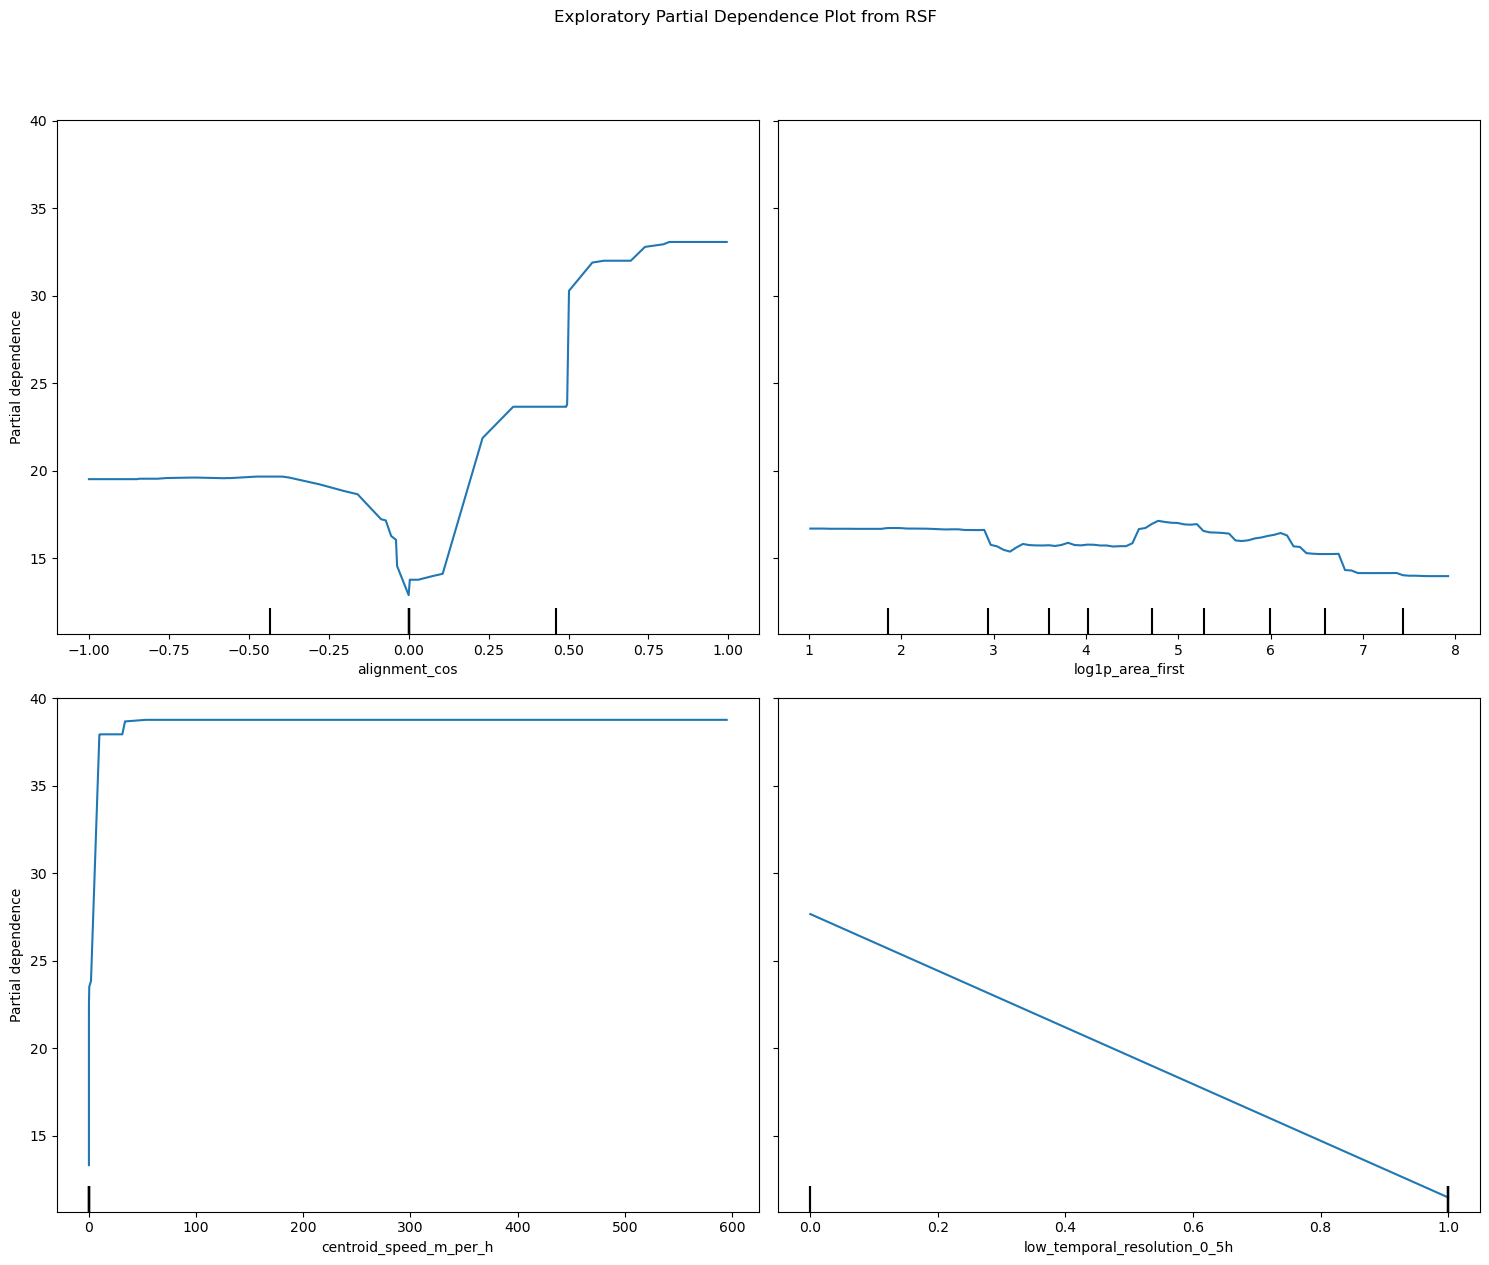

In [6]:
# ==========================================
# Partial Dependence Plot

# ==========================================
# 1. Wrap the RSF model to make it compatible with scikit-learn's partial dependence interface.
class RSF_Wrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
        self.is_fitted_ = True 

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        # Use RSF risk score as the prediction target for PDP
        return self.model.predict(X)

wrapped_rsf = RSF_Wrapper(best_rsf)

# ==========================================
# 2. Select a small set of predictors for exploratory PDPs

features_to_plot = [
    "alignment_cos", "log1p_area_first",
    "centroid_speed_m_per_h", "low_temporal_resolution_0_5h"
]

fig, ax = plt.subplots(2, 2, figsize=(15, 12))
display = PartialDependenceDisplay.from_estimator(
    wrapped_rsf, 
    X_aft, 
    features_to_plot,
    ax=ax,
    kind="average"  # 'average' marginal effect
)
plt.suptitle('Exploratory Partial Dependence Plot from RSF', y=1.05)
plt.tight_layout()
plt.savefig(output_dir / 'rsf_partial_dependence.png', dpi=300, bbox_inches='tight')
plt.show()